In [1]:
# Import libraries
from pathlib import Path
import json
import sys
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

In [2]:
# Set paths
current_path = Path().resolve()
root_path = current_path.parent.parent
scenarios_path = root_path / "scenarios_inputs" / "nie" 
annotated_output_path = root_path / "annotated_outputs" / "nie"

print(f"current_path: {current_path}")
print(f"root_path: {root_path}")
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")

current_path: C:\Users\rylen\Dropbox\2025_moral_scenario_annotation\code\rylen\analysis\nie
root_path: C:\Users\rylen\Dropbox\2025_moral_scenario_annotation\code\rylen
scenarios_path: C:\Users\rylen\Dropbox\2025_moral_scenario_annotation\code\rylen\scenarios_inputs\nie
annotated_output_path: C:\Users\rylen\Dropbox\2025_moral_scenario_annotation\code\rylen\annotated_outputs\nie


In [3]:
# Import locally
sys.path.append(str(root_path))
sys.path.append(str(root_path / "src"))

import src.generic_analysis_utils as analysis_utils

### Get Scenario IDs

In [5]:
with open(scenarios_path / "nie_scenarios.json") as f:
    SCENARIO_LIST = json.load(f)

SCENARIO_ID_LIST = [scenario["id"] for scenario in SCENARIO_LIST]

### Causality & Intentionality

In [13]:
# Create DataFrame for CIK links
cik_df_all = pd.DataFrame()

# For each scenario that we've identified
for i in SCENARIO_ID_LIST:  
    this_scenario = [scenario_dict for scenario_dict in SCENARIO_LIST if scenario_dict["id"] == i]  # Grabs scenario data corresponding to the ID
    scenario_factors = this_scenario[0]["factors"]['1']  # Grabs first action choice of scenario

    if "Causal Role" in scenario_factors.keys(): # Check for relevant Causal Role factor
        # Read the annotated output
        nodes = analysis_utils.read_annotation(annotated_output_path / f"nie_scenarios_{i}_choice_1.json")
        # Extract the CIK links
        cik_df = analysis_utils.get_cik_links(nodes).sort_values('event')
        # Extract utilities                
        util_df= analysis_utils.events_to_utility_df(nodes)

        # Compute mean utility per event
        mean_utils = util_df.mean(axis=1)
        mean_utils_df = pd.DataFrame(mean_utils).reset_index()
        mean_utils_df.columns = ['event', 'mean_utility']

        # Sort both DataFrames by the 'event' column for accurate column copying
        cik_df = cik_df.sort_values("event").reset_index(drop=True)
        mean_utils_df = mean_utils_df.sort_values("event").reset_index(drop=True)
        assert cik_df["event"].tolist() == mean_utils_df["event"].tolist()

        cik_df['utils'] = mean_utils_df['mean_utility']  # Copying over utliity scores

        # Convert + -> 1 and - -> 0
        cik_df['C'] = cik_df['C'].apply(lambda x: 1 if x == '+' else (0 if x == '-' else x))
        cik_df['I'] = cik_df['I'].apply(lambda x: 1 if x == '+' else (0 if x == '-' else x))
        cik_df['K'] = cik_df['K'].apply(lambda x: 1 if x == '+' else (0 if x == '-' else x))

        # Create DataFrame with scenario labels
        cik_df['SID'] = i
        cik_df['Causal Role'] = scenario_factors["Causal Role"]
        cik_df['Beneficiary'] = scenario_factors["Beneficiary"]
        cik_df['Evitability'] = scenario_factors["Evitability"]
        cik_df['Personal Force'] = scenario_factors["Personal Force"]

        # Add to overall DataFrame
        cik_df_all = pd.concat([cik_df_all, cik_df], ignore_index=True)

print(cik_df_all.head().to_string())

                                                              event  C  I  K  utils  SID Causal Role       Beneficiary Evitability Personal Force
0                           I push the heavy worker from the bridge  1  1  1  -94.0   10       Means  Other-beneficial   Avoidable       Personal
1       The heavy worker dies in the collision with the speed-train  1  1  1  -41.0   10       Means  Other-beneficial   Avoidable       Personal
2                            The heavy worker falls onto the tracks  1  1  1  -71.4   10       Means  Other-beneficial   Avoidable       Personal
3  The speed-train stops before reaching the three railroad workers  1  1  1   38.0   10       Means  Other-beneficial   Avoidable       Personal
4                                The three railroad workers survive  1  1  1   71.0   10       Means  Other-beneficial   Avoidable       Personal


In [14]:
# Aggregate by scenario
sid_agg_df = (
    cik_df_all
    .groupby("SID", as_index=False)
    .agg(
        n_events=("event", "count"),
        C_mean=("C", "mean"),
        I_mean=("I", "mean"),
        K_mean=("K", "mean"),
        utils_mean=("utils", "mean"),
        utils_sum=("utils", "sum"),
        Causal_Role=("Causal Role", "first"),
        Beneficiary=("Beneficiary", "first"),
        Evitability=("Evitability", "first"),
        Personal_Force=("Personal Force", "first"),
    )
    .sort_values("SID")
)

print(sid_agg_df.head().to_string())

   SID  n_events  C_mean  I_mean  K_mean  utils_mean   utils_sum  Causal_Role       Beneficiary Evitability Personal_Force
0   10         5     1.0     1.0    1.00  -19.480000  -97.400000        Means  Other-beneficial   Avoidable       Personal
1   11         7     1.0     1.0    1.00  -39.714286 -278.000000        Means  Other-beneficial   Avoidable     Impersonal
2   16         4     1.0     1.0    0.75    5.250000   21.000000        Means   Self-beneficial   Avoidable       Personal
3   17         7     1.0     1.0    1.00    9.523810   66.666667  Side Effect   Self-beneficial   Avoidable     Impersonal
4   18         4     1.0     1.0    0.50   11.437500   45.750000  Side Effect   Self-beneficial   Avoidable       Personal


In [16]:
# Create summary table of CIK values for the Causal Role and Evitability factors
summary_CIK_df = (sid_agg_df
                  .groupby(["Causal_Role", "Evitability"])
                  [["C_mean", "I_mean"]].agg(['mean', 'sem']).reset_index())
print("\nSummary Table of C, I, K values by Causal Role and Evitability:")
print(summary_CIK_df.to_string())


Summary Table of C, I, K values by Causal Role and Evitability:
   Causal_Role Evitability    C_mean              I_mean          
                                mean       sem      mean       sem
0        Means   Avoidable  1.000000  0.000000  0.907143  0.055286
1        Means  Inevitable  0.970175  0.016301  0.853759  0.029755
2  Side Effect   Avoidable  1.000000  0.000000  0.886310  0.058324
3  Side Effect  Inevitable  1.000000  0.000000  0.933333  0.045426


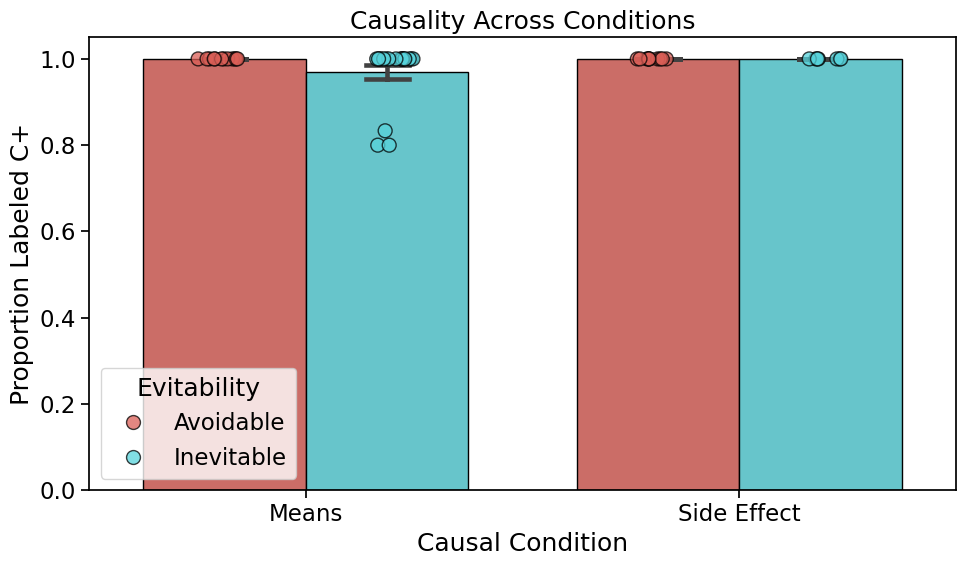

In [18]:
analysis_utils.plot_bar_strip(df=sid_agg_df, x="Causal_Role", y="C_mean", hue="Evitability", 
                              title="Causality Across Conditions", xlabel='Causal Condition', ylabel='Proportion Labeled C+')

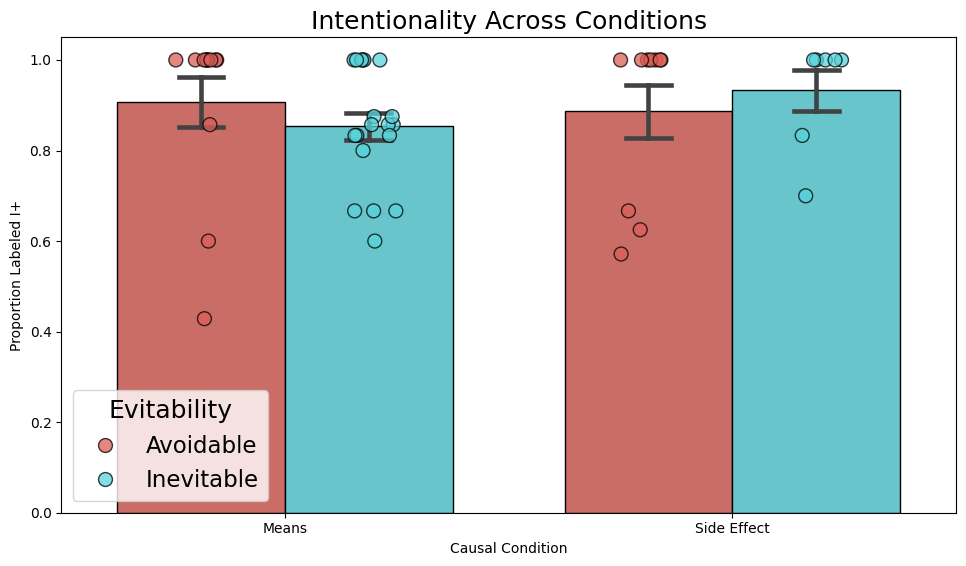

In [17]:
analysis_utils.plot_bar_strip(df=sid_agg_df, x="Causal_Role", y="I_mean", hue="Evitability", 
                              title="Intentionality Across Conditions", xlabel='Causal Condition', ylabel='Proportion Labeled I+')

### Deontology

In [19]:
# Create DataFrame for deontology scores
deont_df_all = pd.DataFrame()

# For each scenario that we've identified
for i in SCENARIO_ID_LIST:  
    this_scenario = [scenario_dict for scenario_dict in SCENARIO_LIST if scenario_dict["id"] == i]  # Grabs scenario data corresponding to the ID
    scenario_factors = this_scenario[0]["factors"]['1']  # Grabs first action choice of scenario

    if "Personal Force" in scenario_factors.keys(): # Check for relevant Personal Force factor
        # Read the annotated output
        nodes = analysis_utils.read_annotation(annotated_output_path / f"nie_scenarios_{i}_choice_1.json")
        # Extract the deontology scores
        deont_value = float(analysis_utils.extract_deontology(nodes))
       
        # Create DataFrame for a scenario
        deont_df = pd.DataFrame({
            "SID": i,
            "Personal Force": scenario_factors['Personal Force'],
            "Annotator Rating": deont_value
        }, index = [0])

        # Concatenate to big DataFrame
        deont_df_all = pd.concat([deont_df_all, deont_df])

print(deont_df_all.head().to_string())

   SID Personal Force  Annotator Rating
0   10       Personal             -72.0
0   11     Impersonal              14.0
0   16       Personal             -33.0
0   17     Impersonal             -69.0
0   18       Personal             -54.0


In [20]:
deont_summary_df = (
    deont_df_all
    .groupby("Personal Force", as_index=False)["Annotator Rating"]
    .agg(mean="mean", se="sem")
)

print(deont_summary_df.to_string(index=False))

Personal Force       mean       se
    Impersonal -32.291667 6.119427
      Personal -42.750000 4.345266


In [21]:
personal_ratings = deont_df_all[deont_df_all['Personal Force'] == 'Personal']['Annotator Rating']
impersonal_ratings = deont_df_all[deont_df_all['Personal Force'] == 'Impersonal']['Annotator Rating']

t_stat, p_value = ttest_ind(personal_ratings, impersonal_ratings)

print(f"\nt-test results:")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")


t-test results:
t-statistic: -1.393
p-value: 0.1702


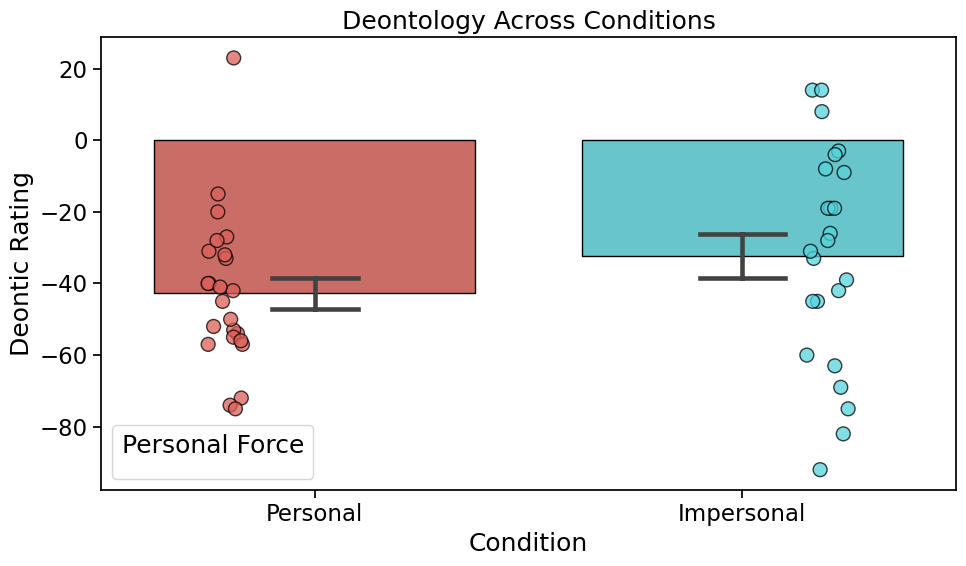

In [23]:
analysis_utils.plot_bar_strip(df=deont_df_all, x="Personal Force", y="Annotator Rating", hue="Personal Force",
                              title="Deontology Across Conditions", xlabel='Condition', ylabel='Deontic Rating')